# 02 — Modelado Predictivo

**Objetivo:** Entrenar y evaluar modelos que expliquen el precio de Equipo 1 y Equipo 2 a partir de las materias primas.

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.append('../src')

from modeling import split_data, train_linear_model, evaluate_model, get_feature_importance

PROCESSED_PATH = Path('../data/processed')
print('Librerías y módulos cargados.')

Librerías y módulos cargados.


## 1. Carga de Datos Procesados



In [5]:
df = pd.read_csv(PROCESSED_PATH / "historico_equipos_limpio.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Dataset procesado cargado correctamente")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Periodo: {df['Date'].min().date()} → {df['Date'].max().date()}")

df.head()

Dataset procesado cargado correctamente
Filas: 3,530
Columnas: 6
Periodo: 2010-01-04 → 2023-08-31


,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.5,2225.25,434.73,931.73
1,2010-01-05,80.59,527.5,2246.50,449.97,968.56
2,2010-01-06,81.89,527.5,2302.50,444.48,960.51
3,2010-01-07,81.51,527.5,2306.50,440.90,960.14
4,2010-01-08,81.37,552.5,2261.25,448.82,949.55


## 2. Preparación de Variables (X, y)

In [6]:
# Variables predictoras
FEATURES = [
    "Price_X",
    "Price_Y",
    "Price_Z"
]

# Objetivos
TARGET_EQUIPO1 = "Price_Equipo1"
TARGET_EQUIPO2 = "Price_Equipo2"


## 3. Entrenamiento de Modelos — Equipo 1

In [18]:
from modeling import (
    time_series_split_data,
    train_linear_model,
    evaluate_model
)

# División temporal
X_train, X_test, y_train, y_test, train_df, test_df = (
    time_series_split_data(
        df=df,
        feature_cols=FEATURES,
        target_col=TARGET_EQUIPO1,
        test_size=0.2
    )
)

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

# Modelo lineal
modelo_equipo1 = train_linear_model(
    X_train,
    y_train,
    model_type="linear"
)

metricas_equipo1 = evaluate_model(
    modelo_equipo1,
    X_test,
    y_test
)

print(
    f"Train: {train_df['Date'].min().date()} -> {train_df['Date'].max().date()}"
)

print(
    f"Test: {test_df['Date'].min().date()} -> {test_df['Date'].max().date()}"
)

Entrenamiento: 2824
Prueba: 706
Train: 2010-01-04 -> 2020-12-07
Test: 2020-12-08 -> 2023-08-31


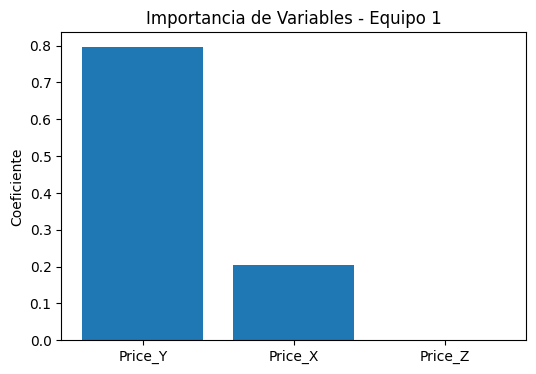

In [22]:
# =====================================================
# IMPORTANCIA DE VARIABLES - EQUIPO 1
# =====================================================
coeficientes = pd.DataFrame({
    "Variable": FEATURES,
    "Coeficiente": modelo_equipo1.coef_
})

coeficientes = coeficientes.sort_values(
    "Coeficiente",
    ascending=False
)

coeficientes
plt.figure(figsize=(6,4))

plt.bar(
    coeficientes["Variable"],
    coeficientes["Coeficiente"]
)

plt.title("Importancia de Variables - Equipo 1")
plt.ylabel("Coeficiente")

plt.show()


## 4. Entrenamiento de Modelos — Equipo 2

In [23]:
from modeling import (
    time_series_split_data,
    train_linear_model,
    evaluate_model
)

# División temporal
X_train, X_test, y_train, y_test, train_df, test_df = (
    time_series_split_data(
        df=df,
        feature_cols=FEATURES,
        target_col=TARGET_EQUIPO2,
        test_size=0.2
    )
)

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

# Modelo lineal
modelo_equipo2 = train_linear_model(
    X_train,
    y_train,
    model_type="linear"
)

metricas_equipo2 = evaluate_model(
    modelo_equipo2,
    X_test,
    y_test
)

print("\nMétricas Equipo 2")
print(metricas_equipo2)

print(
    f"Train: {train_df['Date'].min().date()} -> {train_df['Date'].max().date()}"
)

print(
    f"Test: {test_df['Date'].min().date()} -> {test_df['Date'].max().date()}"
)

Entrenamiento: 2824
Prueba: 706

Métricas Equipo 2
{'RMSE': np.float64(19.3198), 'MAE': 16.5514, 'R2': 0.9853}
Train: 2010-01-04 -> 2020-12-07
Test: 2020-12-08 -> 2023-08-31


,Variable,Coeficiente
0,Price_X,0.341043
1,Price_Y,0.332841
2,Price_Z,0.332109


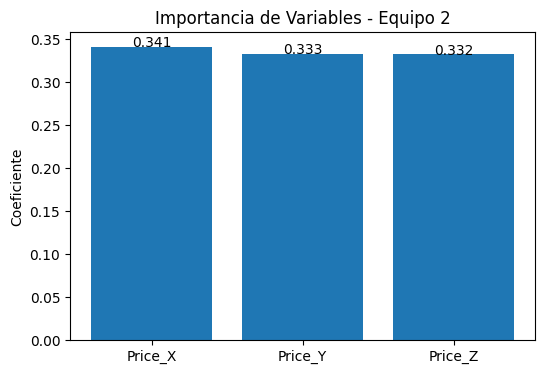

In [26]:
# =====================================================
# IMPORTANCIA DE VARIABLES - EQUIPO 2
# =====================================================

coeficientes_equipo2 = pd.DataFrame({
    "Variable": FEATURES,
    "Coeficiente": modelo_equipo2.coef_
})

coeficientes_equipo2 = coeficientes_equipo2.sort_values(
    "Coeficiente",
    ascending=False
)

display(coeficientes_equipo2)

plt.figure(figsize=(6,4))

bars = plt.bar(
    coeficientes_equipo2["Variable"],
    coeficientes_equipo2["Coeficiente"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha="center"
    )

plt.title("Importancia de Variables - Equipo 2")
plt.ylabel("Coeficiente")
plt.show()

A diferencia del Equipo 1, donde Price_Y tiene una influencia dominante, en el Equipo 2 las tres materias primas presentan coeficientes muy similares, indicando una contribución equilibrada al precio final del equipo
Conclusión:
Aunque en el análisis exploratorio Price_Z presentó la mayor correlación
con el precio del Equipo 2, el modelo lineal distribuye el peso de manera
similar entre las tres materias primas. Esto sugiere que existe información
compartida entre las variables predictoras y que las tres contribuyen al
comportamiento del precio final.


## 5. Comparación de Modelos

In [28]:
# =====================================================
# COMPARACIÓN DE MODELOS FINALES
# =====================================================
#
# Objetivo:
# Comparar el desempeño de los modelos seleccionados
# para cada equipo.
#
# Se utilizan las métricas:
# - RMSE
# - MAE
# - R²
#
# Los modelos seleccionados serán utilizados en la
# fase de forecasting.
# =====================================================

comparacion_modelos = pd.DataFrame([
    {
        "Equipo": "Equipo 1",
        "Modelo": "Regresión Lineal",
        "RMSE": metricas_equipo1["RMSE"],
        "MAE": metricas_equipo1["MAE"],
        "R2": metricas_equipo1["R2"]
    },
    {
        "Equipo": "Equipo 2",
        "Modelo": "Regresión Lineal",
        "RMSE": metricas_equipo2["RMSE"],
        "MAE": metricas_equipo2["MAE"],
        "R2": metricas_equipo2["R2"]
    }
])

display(comparacion_modelos)

,Equipo,Modelo,RMSE,MAE,R2
0,Equipo 1,Regresión Lineal,10.3088,8.8699,0.9913
1,Equipo 2,Regresión Lineal,19.3198,16.5514,0.9853


### Hallazgos

- La regresión lineal obtuvo un desempeño sobresaliente para ambos equipos.
- El modelo explica más del 98% de la variabilidad observada en los precios históricos.
- Las materias primas seleccionadas capturan adecuadamente el comportamiento de los precios de los equipos.
- Los resultados sugieren una relación predominantemente lineal entre las materias primas y los precios finales.

### Modelo seleccionado

Se selecciona la Regresión Lineal como modelo principal debido a:

- Alta precisión predictiva.
- Excelente capacidad explicativa (R² > 0.98).
- Interpretabilidad de los coeficientes.
- Menor complejidad de implementación y mantenimiento.
- Facilidad para comunicar resultados al negocio.

### Equipo 1

Los resultados muestran una relación altamente consistente entre las materias primas y el costo del Equipo 1.

Resultados relevantes:

- R² del modelo lineal: 0.9913
- RMSE: 10.3088
- MAE: 8.8699
- Variable con mayor coeficiente: Price_Y

Se concluye que Price_Y es la materia prima con mayor influencia sobre el comportamiento histórico del Equipo 1.

### Equipo 2

Los resultados muestran una relación altamente consistente entre las materias primas y el costo del Equipo 2.

Resultados relevantes:

- R² del modelo lineal: 0.9853
- RMSE: 19.3198
- MAE: 16.5514
- Los coeficientes presentan valores similares para Price_X, Price_Y y Price_Z.

Esto sugiere que el precio del Equipo 2 depende de manera equilibrada de las tres materias primas consideradas.

### Conclusión General

Las materias primas contienen suficiente información para explicar y anticipar los costos históricos de adquisición de los equipos.

Los modelos de regresión lineal lograron explicar más del 98% de la variabilidad observada para ambos equipos:

- Equipo 1: R² = 0.9913
- Equipo 2: R² = 0.9853

Estos resultados indican que existe una relación predominantemente lineal entre los precios de las materias primas y los costos de los equipos.

Por su precisión, interpretabilidad y simplicidad, la regresión lineal fue seleccionada como el modelo principal para la fase de forecasting.